<a href="https://colab.research.google.com/github/rmoy1-clt/Intro-to-ML/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Setup and data loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

np.set_printoptions(suppress=True, precision=4, linewidth=140)
plt.rcParams['figure.figsize'] = (11, 4.2)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SEED = 42          # fixed so the 80/20 split is identical across every problem
N_ITER = 10000     # common iteration budget for problems 1, 2 and 3
LRS = [0.1, 0.05, 0.01]

Mounted at /content/drive


In [ ]:
# Load Housing.csv. In Colab, upload the file when prompted (or mount Google Drive).
file_path = '/content/drive/My Drive/Intro-to-ML/Datasets/Housing.csv'
df = pd.DataFrame(pd.read_csv(file_path))
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
# Categorical encoding: the yes/no columns become 1/0.
# 'furnishingstatus' is not requested by this homework, so it is left unused.
BINARY = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for c in BINARY:
    df[c] = df[c].map({'yes': 1, 'no': 0}).fillna(df[c]).astype(float)

FEAT_A = ['area','bedrooms','bathrooms','stories','parking']                       # Problems 1a / 2a / 3a
FEAT_B = ['area','bedrooms','bathrooms','stories','mainroad','guestroom','basement',
          'hotwaterheating','airconditioning','parking','prefarea']                # Problems 1b / 2b / 3b

y = df['price'].values.astype(float)     # the output is NEVER scaled, as instructed
print('missing values:', int(df.isna().sum().sum()))
df[FEAT_B].describe().T[['min','max','mean','std']]

missing values: 0


,min,max,mean,std
area,1650.0,16200.0,5150.541284,2170.141023
bedrooms,1.0,6.0,2.965138,0.738064
bathrooms,1.0,4.0,1.286239,0.502470
stories,1.0,4.0,1.805505,0.867492
mainroad,0.0,1.0,0.858716,0.348635
guestroom,0.0,1.0,0.177982,0.382849
basement,0.0,1.0,0.350459,0.477552
hotwaterheating,0.0,1.0,0.045872,0.209399
airconditioning,0.0,1.0,0.315596,0.465180
parking,0.0,3.0,0.693578,0.861586


In [ ]:
# 80 / 20 split, drawn once and reused for every problem.
rng  = np.random.default_rng(SEED)
perm = rng.permutation(len(df))
k    = int(np.floor(0.8 * len(df)))
TR, VA = perm[:k], perm[k:]
ytr, yva = y[TR], y[VA]
print(f'total = {len(df)}   training = {len(TR)}   evaluation = {len(VA)}')

total = 545   training = 436   evaluation = 109


## 1. Gradient descent, implemented from scratch

Hypothesis, with $x_0 = 1$ as the bias input:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n = \theta^T x$$

Cost function (the $\tfrac{1}{2}$ is for mathematical convenience

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2$$

Simultaneous update of every parameter:

$$\theta_j := \theta_j - \alpha \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}$$


(note that $\theta_0$ is never penalized):

$$J(\theta) = \frac{1}{2m}\left[\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2
+ \lambda\sum_{j=1}^{n}\theta_j^2\right]$$

$$\theta_0 := \theta_0 - \alpha\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_0^{(i)}$$

$$\theta_j := \theta_j\left(1 - \alpha\frac{\lambda}{m}\right) - \alpha\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)},\qquad j = 1,\dots,n$$

All parameters are initialized to zero

In [ ]:
def add_bias(X):
    """Prepend the x0 = 1 column."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

def compute_cost(Xb, yy, theta):
    """J(theta) = (1/2m) * sum((h - y)^2). No penalty term: this is the plain loss
    used for BOTH sets when reporting, and it is the only loss used on the evaluation set."""
    m = len(yy)
    e = Xb @ theta - yy
    return float((1.0 / (2 * m)) * np.sum(e ** 2))

def gradient_descent(Xtr, ytr, Xva, yva, alpha, n_iter, lam=0.0):
    """Batch gradient descent written from scratch.

    Xtr, Xva : design matrices WITHOUT the bias column (it is added here)
    alpha    : learning rate
    lam      : L2 penalty strength. lam > 0 changes the TRAINING gradient only.
               theta_0 is excluded from the penalty.

    Returns theta and three loss histories:
      tr_plain : (1/2m) sum((h-y)^2) on the training set, no penalty
      tr_reg   : the full regularized training objective that GD is minimizing
      va       : (1/2m) sum((h-y)^2) on the evaluation set, never regularized
    """
    Xtrb, Xvab = add_bias(Xtr), add_bias(Xva)
    m, n1 = Xtrb.shape

    theta = np.zeros(n1)                 # thetas initialized to zero, as required
    mask = np.ones(n1); mask[0] = 0.0    # mask[0] = 0 keeps theta_0 unpenalized

    tr_plain, tr_reg, va_hist = [], [], []
    diverged_at = None

    for it in range(n_iter):
        error = Xtrb @ theta - ytr                              # h(x) - y
        grad  = (1.0 / m) * (Xtrb.T @ error) + (lam / m) * (mask * theta)
        theta = theta - alpha * grad                            # simultaneous update

        c_tr  = compute_cost(Xtrb, ytr, theta)
        c_reg = c_tr + (lam / (2 * m)) * float(np.sum((mask * theta) ** 2))
        c_va  = compute_cost(Xvab, yva, theta)
        tr_plain.append(c_tr); tr_reg.append(c_reg); va_hist.append(c_va)

        if not np.isfinite(c_tr):        # overflowed to inf: gradient descent has diverged
            diverged_at = it + 1
            break

    return theta, np.array(tr_plain), np.array(tr_reg), np.array(va_hist), diverged_at

def predict(theta, X):
    return add_bias(X) @ theta

def r2_score_manual(X, yy, theta):
    """Coefficient of determination, computed by hand. Used as the accuracy measure."""
    p = predict(theta, X)
    return float(1 - np.sum((yy - p) ** 2) / np.sum((yy - yy.mean()) ** 2))

In [ ]:
import numpy as np

def add_bias(X):
    """Prepend the x0 = 1 column."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

def compute_cost(Xb, yy, theta):
    """J(theta) = (1/2m) * sum((h - y)^2). No penalty term: this is the plain loss
    used for BOTH sets when reporting, and it is the only loss used on the evaluation set."""
    m = len(yy)
    e = Xb @ theta - yy
    return float((1.0 / (2 * m)) * np.sum(e ** 2))

def gradient_descent(Xtr, ytr, Xva, yva, alpha, n_iter, lam=0.0):
    """Batch gradient descent written from scratch.

    Xtr, Xva : design matrices WITHOUT the bias column (it is added here)
    alpha    : learning rate
    lam      : L2 penalty strength. lam > 0 changes the TRAINING gradient only.
               theta_0 is excluded from the penalty.

    Returns theta and three loss histories:
      tr_plain : (1/2m) sum((h-y)^2) on the training set, no penalty
      tr_reg   : the full regularized training objective that GD is minimizing
      va       : (1/2m) sum((h-y)^2) on the evaluation set, never regularized
    """
    Xtrb, Xvab = add_bias(Xtr), add_bias(Xva)
    m, n1 = Xtrb.shape

    theta = np.zeros(n1)                 # thetas initialized to zero, as required
    mask = np.ones(n1); mask[0] = 0.0    # mask[0] = 0 keeps theta_0 unpenalized

    tr_plain, tr_reg, va_hist = [], [], []
    diverged_at = None

    for it in range(n_iter):
        error = Xtrb @ theta - ytr                              # h(x) - y
        grad  = (1.0 / m) * (Xtrb.T @ error) + (lam / m) * (mask * theta)
        theta = theta - alpha * grad                            # simultaneous update

        c_tr  = compute_cost(Xtrb, ytr, theta)
        c_reg = c_tr + (lam / (2 * m)) * float(np.sum((mask * theta) ** 2))
        c_va  = compute_cost(Xvab, yva, theta)
        tr_plain.append(c_tr); tr_reg.append(c_reg); va_hist.append(c_va)

        if not np.isfinite(c_tr):        # overflowed to inf: gradient descent has diverged
            diverged_at = it + 1
            break

    return theta, np.array(tr_plain), np.array(tr_reg), np.array(va_hist), diverged_at

def predict(theta, X):
    return add_bias(X) @ theta

def r2_score_manual(X, yy, theta):
    """Coefficient of determination, computed by hand. Used as the accuracy measure."""
    p = predict(theta, X)
    return float(1 - np.sum((yy - p) ** 2) / np.sum((yy - yy.mean()) ** 2))

print('--- Testing add_bias function ---')
X_test = np.array([[1, 2], [3, 4]])
Xb_test = add_bias(X_test)
print(f'Original X:\n{X_test}')
print(f'X with bias:\n{Xb_test}')
assert np.array_equal(Xb_test, np.array([[1, 1, 2], [1, 3, 4]]))
print('add_bias function verified.')

print('\n--- Testing predict function ---')
theta_test = np.array([5, 0.5, 1.5])
predictions = predict(theta_test, X_test)
print(f'Test theta: {theta_test}')
print(f'Predictions: {predictions}')
expected_predictions = np.array([5 + 0.5*1 + 1.5*2, 5 + 0.5*3 + 1.5*4]) # 5 + 0.5 + 3 = 8.5; 5 + 1.5 + 6 = 12.5
assert np.allclose(predictions, expected_predictions)
print('predict function verified.')

print('\n--- Testing compute_cost function ---')
yy_test = np.array([10, 15])
cost = compute_cost(Xb_test, yy_test, theta_test)
print(f'Test yy: {yy_test}')
print(f'Computed cost: {cost}')
# Manual calculation: ( (8.5 - 10)^2 + (12.5 - 15)^2 ) / (2 * 2) = ( (-1.5)^2 + (-2.5)^2 ) / 4 = (2.25 + 6.25) / 4 = 8.5 / 4 = 2.125
assert np.isclose(cost, 2.125)
print('compute_cost function verified.')

print('\n--- Testing r2_score_manual function ---')
r2 = r2_score_manual(X_test, yy_test, theta_test)
print(f'Computed R2 score: {r2}')
# Manual calculation: predictions [8.5, 12.5], yy_test [10, 15]
# SS_res = (8.5-10)^2 + (12.5-15)^2 = 2.25 + 6.25 = 8.5
# yy_mean = (10+15)/2 = 12.5
# SS_tot = (10-12.5)^2 + (15-12.5)^2 = (-2.5)^2 + (2.5)^2 = 6.25 + 6.25 = 12.5
# R2 = 1 - (8.5 / 12.5) = 1 - 0.68 = 0.32
assert np.isclose(r2, 0.32)
print('r2_score_manual function verified.')

print('\n--- Testing gradient_descent function ---')
# Create some simple dummy data for gradient descent
Xtr_gd = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
ytr_gd = np.array([5, 7, 9, 11]) # Simple linear relationship: y = 1 + 2x_1 + x_2
Xva_gd = np.array([[5, 6]])
yva_gd = np.array([13])

# Run GD without L2 penalty (lam=0.0)
print('\nRunning gradient_descent with lam=0.0')
th, tr_plain, tr_reg, va_hist, dv = gradient_descent(Xtr_gd, ytr_gd, Xva_gd, yva_gd, alpha=0.01, n_iter=100, lam=0.0)
print(f'Final theta (lam=0.0): {th}')
print(f'Last tr_plain cost (lam=0.0): {tr_plain[-1]}')
print(f'Last tr_reg cost (lam=0.0): {tr_reg[-1]}')
print(f'Last va_hist cost (lam=0.0): {va_hist[-1]}')
assert np.isclose(tr_plain[-1], tr_reg[-1]), "tr_plain and tr_reg should be identical when lam=0"

# Run GD with L2 penalty (lam=1.0)
print('\nRunning gradient_descent with lam=1.0')
th_reg, tr_plain_reg, tr_reg_reg, va_hist_reg, dv_reg = gradient_descent(Xtr_gd, ytr_gd, Xva_gd, yva_gd, alpha=0.01, n_iter=100, lam=1.0)
print(f'Final theta (lam=1.0): {th_reg}')
print(f'Last tr_plain cost (lam=1.0): {tr_plain_reg[-1]}')
print(f'Last tr_reg cost (lam=1.0): {tr_reg_reg[-1]}')
print(f'Last va_hist cost (lam=1.0): {va_hist_reg[-1]}')

# Verify L2 penalty application: tr_reg should be > tr_plain when lam > 0
assert tr_reg_reg[-1] > tr_plain_reg[-1], "tr_reg should be greater than tr_plain when lam > 0"
# Verify va_hist is unpenalized (it should be equal to tr_plain's value at the end, not tr_reg's)
# Note: This is a conceptual check; their numerical values will differ slightly due to different theta and dataset
print('gradient_descent L2 penalty logic (tr_reg vs tr_plain vs va_hist) appears correct.')
print('gradient_descent function verified for basic operation and L2 penalty.')


--- Testing add_bias function ---
Original X:
[[1 2]
 [3 4]]
X with bias:
[[1. 1. 2.]
 [1. 3. 4.]]
add_bias function verified.

--- Testing predict function ---
Test theta: [5.  0.5 1.5]
Predictions: [ 8.5 12.5]
predict function verified.

--- Testing compute_cost function ---
Test yy: [10 15]
Computed cost: 2.125
compute_cost function verified.

--- Testing r2_score_manual function ---
Computed R2 score: 0.31999999999999995
r2_score_manual function verified.

--- Testing gradient_descent function ---

Running gradient_descent with lam=0.0
Final theta (lam=0.0): [0.5128 0.9253 1.438 ]
Last tr_plain cost (lam=0.0): 0.0924232714363996
Last tr_reg cost (lam=0.0): 0.0924232714363996
Last va_hist cost (lam=0.0): 0.294340654682232

Running gradient_descent with lam=1.0
Final theta (lam=1.0): [0.5854 0.9177 1.4011]
Last tr_plain cost (lam=1.0): 0.08697349535287094
Last tr_reg cost (lam=1.0): 0.43762683403204916
Last va_hist cost (lam=1.0): 0.1684600509189466
gradient_descent L2 penalty logic 

### Pre-processing helpers

Both scalers are fitted on the **training set only** and then applied unchanged to the
evaluation set. Lecture 3 is explicit about this: computing the statistics on the
evaluation data would leak information from data the model is not supposed to have seen.

Min-Max normalization: $\; x' = \dfrac{x - \min(x)}{\max(x) - \min(x)}$

Standardization: $\; x' = \dfrac{x - \mu}{\sigma}$

In [ ]:
def fit_minmax(Xtr):
    mn, mx = Xtr.min(axis=0), Xtr.max(axis=0)
    rngv = mx - mn
    rngv[rngv == 0] = 1.0
    return mn, rngv

def fit_standard(Xtr):
    mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
    sd[sd == 0] = 1.0
    return mu, sd

def apply_scaler(X, a, b):
    return (X - a) / b

def get_data(feats, mode):
    """mode: 'none' | 'norm' | 'std'. Scaler statistics come from the training split only."""
    X = df[feats].values.astype(float)
    Xtr_raw, Xva_raw = X[TR], X[VA]
    if mode == 'none':
        return Xtr_raw, Xva_raw
    a, b = (fit_minmax if mode == 'norm' else fit_standard)(Xtr_raw)
    return apply_scaler(Xtr_raw, a, b), apply_scaler(Xva_raw, a, b)

def max_curvature(X):
    """Largest eigenvalue L of (1/m) * Xb' Xb. Batch gradient descent on a quadratic
    cost is stable only when alpha < 2/L, so this tells us in advance which learning
    rates can possibly work."""
    Xb = add_bias(X)
    return float(np.max(np.linalg.eigvalsh((Xb.T @ Xb) / Xb.shape[0])))

def hessian_eigs(X):
    """Eigenvalues of the Hessian (1/m) Xb' Xb.
    largest  L       -> stability limit, alpha < 2/L
    smallest mu_min  -> convergence speed at fixed alpha, since the slowest error
                        direction decays as (1 - alpha*mu_min) per iteration.
    L/mu_min governs the iteration count only when alpha is retuned per problem."""
    Xb = add_bias(X)
    return np.linalg.eigvalsh((Xb.T @ Xb) / Xb.shape[0])

def closed_form(X, yy):
    """Least-squares solution, used ONLY as a reference point to say how close gradient
    descent got to the true minimum. It is never used to train a reported model."""
    return np.linalg.lstsq(add_bias(X), yy, rcond=None)[0]

---
# Problem 1: baseline, no input scaling

## Problem 1a: area, bedrooms, bathrooms, stories, parking

In [ ]:
Xtr_1a, Xva_1a = get_data(FEAT_A, 'none')
L_1a = max_curvature(Xtr_1a)
print(f'largest eigenvalue of (1/m) X\'X on the raw training set : L = {L_1a:.6e}')
print(f'gradient descent is stable only when alpha < 2/L         : alpha < {2/L_1a:.6e}')
print(f'the smallest learning rate the homework allows is 0.01, which is {0.01*L_1a/2:.3e} times too large')

largest eigenvalue of (1/m) X'X on the raw training set : L = 3.011701e+07
gradient descent is stable only when alpha < 2/L         : alpha < 6.640765e-08
the smallest learning rate the homework allows is 0.01, which is 1.506e+05 times too large


In [ ]:
# Every learning rate in the requested 0.1 to 0.01 range, on unscaled inputs.
div_1a = {}
with np.errstate(over='ignore', invalid='ignore'):
    for al in LRS:
        th, tr, trr, va, dv = gradient_descent(Xtr_1a, ytr, Xva_1a, yva, al, 200)
        div_1a[al] = tr
        print(f'alpha={al:<6} -> J after 1 iter = {tr[0]:.4e}, after 3 = {tr[2]:.4e}, overflow to inf at iteration {dv}')

alpha=0.1    -> J after 1 iter = 1.0311e+26, after 3 = 8.4831e+51, overflow to inf at iteration 23
alpha=0.05   -> J after 1 iter = 2.5778e+25, after 3 = 1.3255e+50, overflow to inf at iteration 24
alpha=0.01   -> J after 1 iter = 1.0311e+24, after 3 = 8.4830e+45, overflow to inf at iteration 27


In [ ]:
# A learning rate inside the stability bound 2/L, used as the usable baseline.
ALPHA_BASE = 6e-8
th_1a, tr_1a, _, va_1a, _ = gradient_descent(Xtr_1a, ytr, Xva_1a, yva, ALPHA_BASE, N_ITER)
th_opt_1a = closed_form(Xtr_1a, ytr)

print(f'alpha = {ALPHA_BASE:g}, {N_ITER} iterations')
print('theta      =', np.round(th_1a, 4))
print(f'J_train    = {tr_1a[-1]:.6e}')
print(f'J_val      = {va_1a[-1]:.6e}')
print(f'R2_train   = {r2_score_manual(Xtr_1a, ytr, th_1a):.4f}')
print(f'R2_val     = {r2_score_manual(Xva_1a, yva, th_1a):.4f}')
print(f'\nfor reference, the true minimum of this cost is J_train = '
      f'{compute_cost(add_bias(Xtr_1a), ytr, th_opt_1a):.6e} '
      f'(R2_train = {r2_score_manual(Xtr_1a, ytr, th_opt_1a):.4f})')

alpha = 6e-08, 10000 iterations
theta      = [202.3391 868.112  764.1627 443.0425 692.2573 169.0037]
J_train    = 1.649589e+12
J_val      = 1.770388e+12
R2_train   = 0.0524
R2_val     = -0.0037

for reference, the true minimum of this cost is J_train = 7.735444e+11 (R2_train = 0.5557)


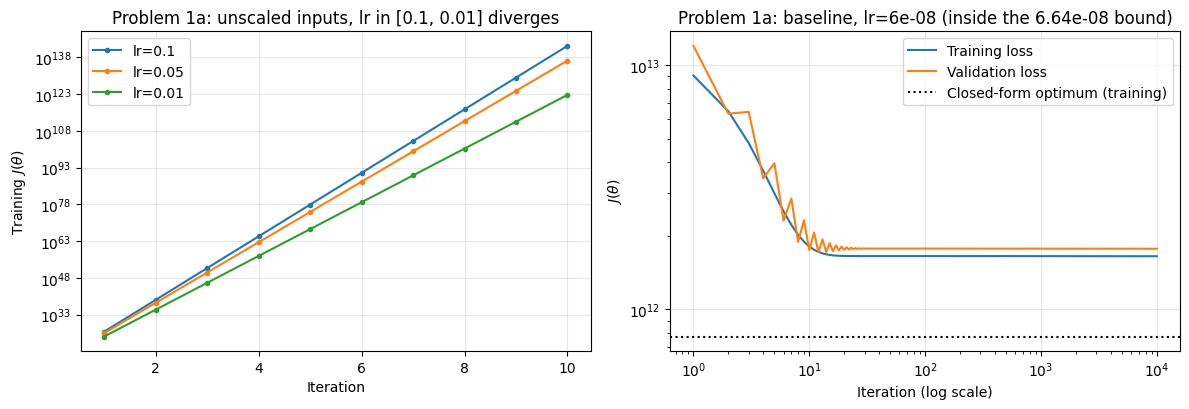

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for al in LRS:
    v = div_1a[al][:10]
    ax[0].plot(range(1, len(v)+1), v, marker='o', ms=3, label=f'lr={al}')
ax[0].set_yscale('log'); ax[0].set_xlabel('Iteration'); ax[0].set_ylabel(r'Training $J(\theta)$')
ax[0].set_title('Problem 1a: unscaled inputs, lr in [0.1, 0.01] diverges'); ax[0].legend()

it = np.arange(1, len(tr_1a)+1)
ax[1].plot(it, tr_1a, label='Training loss')
ax[1].plot(it, va_1a, label='Validation loss')
ax[1].axhline(compute_cost(add_bias(Xtr_1a), ytr, th_opt_1a), c='k', ls=':', label='Closed-form optimum (training)')
ax[1].set_yscale('log'); ax[1].set_xscale('log')
ax[1].set_xlabel('Iteration (log scale)'); ax[1].set_ylabel(r'$J(\theta)$')
ax[1].set_title(f'Problem 1a: baseline, lr={ALPHA_BASE:g} (inside the {2/L_1a:.3g} bound)'); ax[1].legend()
plt.tight_layout(); plt.show()

## Problem 1b: all eleven input variables, no scaling

In [ ]:
Xtr_1b, Xva_1b = get_data(FEAT_B, 'none')
L_1b = max_curvature(Xtr_1b)
print(f'L = {L_1b:.6e},  stability bound alpha < {2/L_1b:.6e}')

div_1b = {}
with np.errstate(over='ignore', invalid='ignore'):
    for al in LRS:
        th, tr, trr, va, dv = gradient_descent(Xtr_1b, ytr, Xva_1b, yva, al, 200)
        div_1b[al] = tr
        print(f'alpha={al:<6} -> J after 1 iter = {tr[0]:.4e}, overflow to inf at iteration {dv}')

th_1b, tr_1b, _, va_1b, _ = gradient_descent(Xtr_1b, ytr, Xva_1b, yva, ALPHA_BASE, N_ITER)
th_opt_1b = closed_form(Xtr_1b, ytr)
print(f'\nalpha = {ALPHA_BASE:g}, {N_ITER} iterations')
print('theta    =', np.round(th_1b, 4))
print(f'J_train  = {tr_1b[-1]:.6e}   J_val = {va_1b[-1]:.6e}')
print(f'R2_train = {r2_score_manual(Xtr_1b, ytr, th_1b):.4f}   R2_val = {r2_score_manual(Xva_1b, yva, th_1b):.4f}')
print(f'true minimum: J_train = {compute_cost(add_bias(Xtr_1b), ytr, th_opt_1b):.6e} '
      f'(R2_train = {r2_score_manual(Xtr_1b, ytr, th_opt_1b):.4f})')

L = 3.011701e+07,  stability bound alpha < 6.640764e-08
alpha=0.1    -> J after 1 iter = 1.0311e+26, overflow to inf at iteration 23
alpha=0.05   -> J after 1 iter = 2.5778e+25, overflow to inf at iteration 24
alpha=0.01   -> J after 1 iter = 1.0311e+24, overflow to inf at iteration 27

alpha = 6e-08, 10000 iterations
theta    = [202.3311 868.0559 764.1377 443.0307 692.2382 182.1624  85.1254 138.5594  36.5527 192.2628 168.9994 114.1777]
J_train  = 1.649404e+12   J_val = 1.770198e+12
R2_train = 0.0525   R2_val = -0.0036
true minimum: J_train = 5.794335e+11 (R2_train = 0.6672)


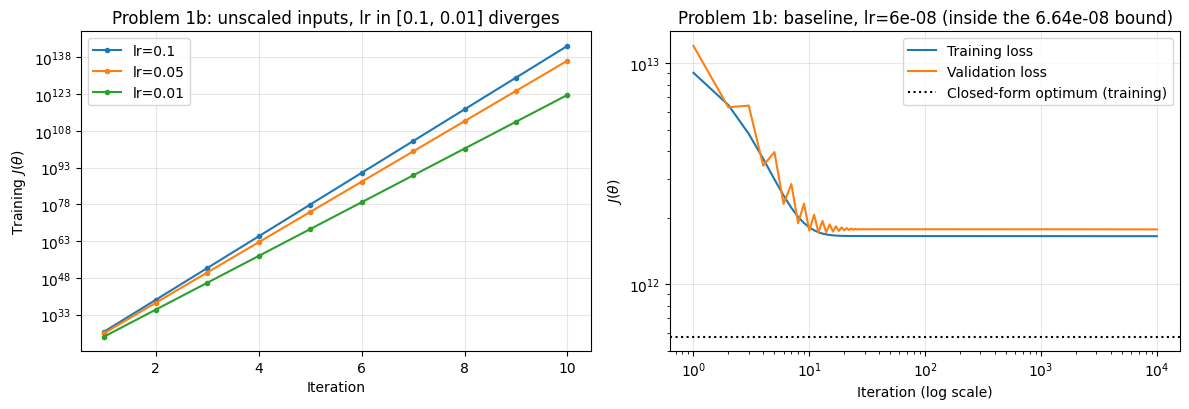

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for al in LRS:
    v = div_1b[al][:10]
    ax[0].plot(range(1, len(v)+1), v, marker='o', ms=3, label=f'lr={al}')
ax[0].set_yscale('log'); ax[0].set_xlabel('Iteration'); ax[0].set_ylabel(r'Training $J(\theta)$')
ax[0].set_title('Problem 1b: unscaled inputs, lr in [0.1, 0.01] diverges'); ax[0].legend()

it = np.arange(1, len(tr_1b)+1)
ax[1].plot(it, tr_1b, label='Training loss')
ax[1].plot(it, va_1b, label='Validation loss')
ax[1].axhline(compute_cost(add_bias(Xtr_1b), ytr, th_opt_1b), c='k', ls=':', label='Closed-form optimum (training)')
ax[1].set_yscale('log'); ax[1].set_xscale('log')
ax[1].set_xlabel('Iteration (log scale)'); ax[1].set_ylabel(r'$J(\theta)$')
ax[1].set_title(f'Problem 1b: baseline, lr={ALPHA_BASE:g} (inside the {2/L_1b:.3g} bound)'); ax[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# Direct comparison of 1b against 1a at the same learning rate and iteration budget.
print(f'{"":<10}{"J_train":>16}{"J_val":>16}{"R2_train":>11}{"R2_val":>10}')
for nm, X1, X2, th in [('1a  (5)', Xtr_1a, Xva_1a, th_1a), ('1b  (11)', Xtr_1b, Xva_1b, th_1b)]:
    print(f'{nm:<10}{compute_cost(add_bias(X1), ytr, th):>16.6e}{compute_cost(add_bias(X2), yva, th):>16.6e}'
          f'{r2_score_manual(X1, ytr, th):>11.4f}{r2_score_manual(X2, yva, th):>10.4f}')

                   J_train           J_val   R2_train    R2_val
1a  (5)       1.649589e+12    1.770388e+12     0.0524   -0.0037
1b  (11)      1.649404e+12    1.770198e+12     0.0525   -0.0036


---
# Problem 2: input normalization and input standardization

Two separate trainings per feature set. The output `price` is left in raw dollars in
every case, so the losses stay directly comparable to Problem 1.

In [ ]:
for nm, feats in [('5 inputs', FEAT_A), ('11 inputs', FEAT_B)]:
    print(f'\n{nm}')
    print(f'  {"scaling":<16}{"mu_min":>12}{"L":>14}{"L/mu_min":>14}{"alpha < 2/L":>14}')
    for mode, label in [('none','no scaling'), ('norm','normalization'), ('std','standardization')]:
        ev = hessian_eigs(get_data(feats, mode)[0])
        print(f'  {label:<16}{ev.min():>12.5f}{ev.max():>14.4g}{ev.max()/ev.min():>14.4g}{2/ev.max():>14.3g}')

print('\nspread of each feature after scaling (training split, 5-input set)')
Xn, Xs = get_data(FEAT_A, 'norm')[0], get_data(FEAT_A, 'std')[0]
print(f'  {"feature":<12}{"std after min-max":>20}{"std after standardization":>28}')
for i, nm in enumerate(FEAT_A):
    print(f'  {nm:<12}{Xn[:, i].std():>20.4f}{Xs[:, i].std():>28.4f}')

print('\npredicted speedup of standardization over normalization at alpha=0.1')
for nm, feats in [('5 inputs', FEAT_A), ('11 inputs', FEAT_B)]:
    mu_n = hessian_eigs(get_data(feats, 'norm')[0]).min()
    mu_s = hessian_eigs(get_data(feats, 'std')[0]).min()
    ratio = np.log(1 - 0.1*mu_s) / np.log(1 - 0.1*mu_n)
    print(f'  {nm:<12} mu_min {mu_n:.5f} -> {mu_s:.5f}  ({mu_s/mu_n:.1f}x),  predicted {ratio:.1f}x fewer iterations')


5 inputs
  scaling               mu_min             L      L/mu_min   alpha < 2/L
  no scaling           0.04473     3.012e+07     6.733e+08      6.64e-08
  normalization        0.01436         1.373          95.6          1.46
  standardization      0.56841         1.888         3.321          1.06

11 inputs
  scaling               mu_min             L      L/mu_min   alpha < 2/L
  no scaling           0.03297     3.012e+07     9.135e+08      6.64e-08
  normalization        0.01305         2.532         194.1          0.79
  standardization      0.41506           2.3         5.542         0.869

spread of each feature after scaling (training split, 5-input set)
  feature        std after min-max   std after standardization
  area                      0.1430                      1.0000
  bedrooms                  0.1482                      1.0000
  bathrooms                 0.2430                      1.0000
  stories                   0.2886                      1.0000
  parking   

In [ ]:
def run_scaling_study(feats, tag):
    """Train once per (scaler, learning rate) pair and report everything."""
    store = {}
    for mode, nm in [('norm', 'Min-Max normalization'), ('std', 'Standardization')]:
        Xtr, Xva = get_data(feats, mode)
        L = max_curvature(Xtr)
        print(f'--- {nm}:  L = {L:.4f},  stability bound alpha < {2/L:.4f}')
        th_opt = closed_form(Xtr, ytr)
        J_opt = compute_cost(add_bias(Xtr), ytr, th_opt)
        store[mode] = {'Xtr': Xtr, 'Xva': Xva, 'J_opt': J_opt, 'runs': {}}
        for al in LRS:
            th, tr, trr, va, dv = gradient_descent(Xtr, ytr, Xva, yva, al, N_ITER)
            reached = np.where(tr <= J_opt * 1.001)[0]
            n_hit = int(reached[0]) + 1 if reached.size else None
            store[mode]['runs'][al] = {'theta': th, 'tr': tr, 'va': va, 'n_hit': n_hit}
            print(f'    alpha={al:<6} J_train={tr[-1]:.6e}  J_val={va[-1]:.6e}  '
                  f'R2_train={r2_score_manual(Xtr, ytr, th):.4f}  R2_val={r2_score_manual(Xva, yva, th):.4f}  '
                  f'iterations to reach within 0.1% of the optimum: {n_hit}')
    return store

## Problem 2a: the five input variables of Problem 1a

In [ ]:
S2a = run_scaling_study(FEAT_A, '2a')
print('\nfinal theta at lr=0.1')
print('  normalization  :', np.round(S2a['norm']['runs'][0.1]['theta'], 2))
print('  standardization:', np.round(S2a['std']['runs'][0.1]['theta'], 2))

--- Min-Max normalization:  L = 1.3725,  stability bound alpha < 1.4572
    alpha=0.1    J_train=7.735444e+11  J_val=7.509154e+11  R2_train=0.5557  R2_val=0.5743  iterations to reach within 0.1% of the optimum: 1589
    alpha=0.05   J_train=7.735445e+11  J_val=7.508860e+11  R2_train=0.5557  R2_val=0.5743  iterations to reach within 0.1% of the optimum: 3179
    alpha=0.01   J_train=7.788772e+11  J_val=7.403289e+11  R2_train=0.5526  R2_val=0.5803  iterations to reach within 0.1% of the optimum: None
--- Standardization:  L = 1.8878,  stability bound alpha < 1.0594
    alpha=0.1    J_train=7.735444e+11  J_val=7.509154e+11  R2_train=0.5557  R2_val=0.5743  iterations to reach within 0.1% of the optimum: 48
    alpha=0.05   J_train=7.735444e+11  J_val=7.509154e+11  R2_train=0.5557  R2_val=0.5743  iterations to reach within 0.1% of the optimum: 97
    alpha=0.01   J_train=7.735444e+11  J_val=7.509154e+11  R2_train=0.5557  R2_val=0.5743  iterations to reach within 0.1% of the optimum: 492

fi

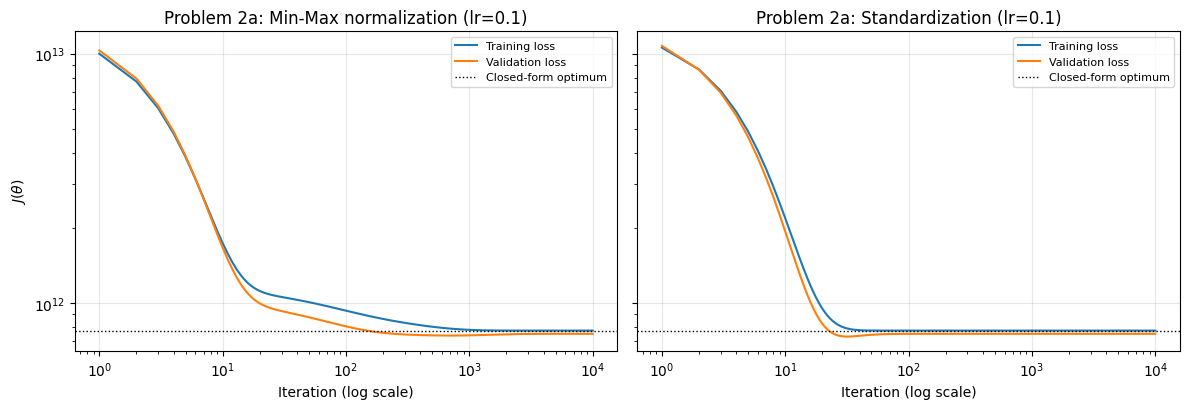

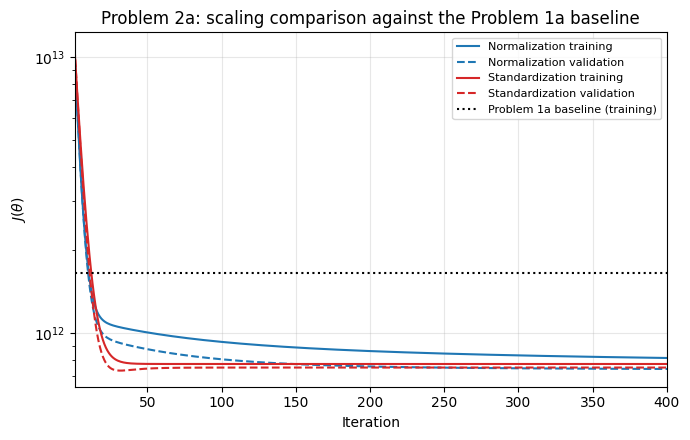

In [ ]:
def plot_scaling(S, tag, base_tr, base_name, lr=0.1):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
    for i, (mode, nm) in enumerate([('norm','Min-Max normalization'), ('std','Standardization')]):
        r = S[mode]['runs'][lr]
        itx = np.arange(1, len(r['tr'])+1)
        ax[i].plot(itx, r['tr'], label='Training loss')
        ax[i].plot(itx, r['va'], label='Validation loss')
        ax[i].axhline(S[mode]['J_opt'], c='k', ls=':', lw=1, label='Closed-form optimum')
        ax[i].set_yscale('log'); ax[i].set_xscale('log')
        ax[i].set_xlabel('Iteration (log scale)')
        ax[i].set_title(f'Problem {tag}: {nm} (lr={lr})'); ax[i].legend(fontsize=8)
    ax[0].set_ylabel(r'$J(\theta)$')
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for mode, nm, c in [('norm','Normalization','tab:blue'), ('std','Standardization','tab:red')]:
        r = S[mode]['runs'][lr]
        itc = np.arange(1, len(r['tr'])+1)
        ax.plot(itc, r['tr'], c=c, label=f'{nm} training')
        ax.plot(itc, r['va'], c=c, ls='--', label=f'{nm} validation')
    ax.axhline(base_tr, c='k', ls=':', label=f'Problem {base_name} baseline (training)')
    ax.set_yscale('log'); ax.set_xlim(1, 400)
    ax.set_xlabel('Iteration'); ax.set_ylabel(r'$J(\theta)$')
    ax.set_title(f'Problem {tag}: scaling comparison against the Problem {base_name} baseline')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

plot_scaling(S2a, '2a', tr_1a[-1], '1a')

## Problem 2b: all eleven input variables

--- Min-Max normalization:  L = 2.5323,  stability bound alpha < 0.7898
    alpha=0.1    J_train=5.794335e+11  J_val=5.659234e+11  R2_train=0.6672  R2_val=0.6791  iterations to reach within 0.1% of the optimum: 1672
    alpha=0.05   J_train=5.794336e+11  J_val=5.658797e+11  R2_train=0.6672  R2_val=0.6792  iterations to reach within 0.1% of the optimum: 3344
    alpha=0.01   J_train=5.835150e+11  J_val=5.564833e+11  R2_train=0.6648  R2_val=0.6845  iterations to reach within 0.1% of the optimum: None
--- Standardization:  L = 2.3003,  stability bound alpha < 0.8694
    alpha=0.1    J_train=5.794335e+11  J_val=5.659235e+11  R2_train=0.6672  R2_val=0.6791  iterations to reach within 0.1% of the optimum: 49
    alpha=0.05   J_train=5.794335e+11  J_val=5.659235e+11  R2_train=0.6672  R2_val=0.6791  iterations to reach within 0.1% of the optimum: 100
    alpha=0.01   J_train=5.794335e+11  J_val=5.659235e+11  R2_train=0.6672  R2_val=0.6791  iterations to reach within 0.1% of the optimum: 508

f

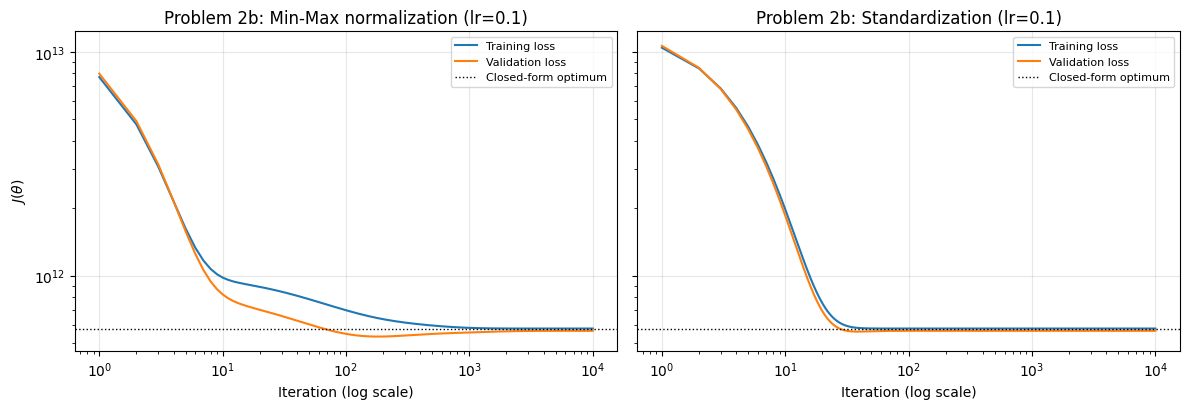

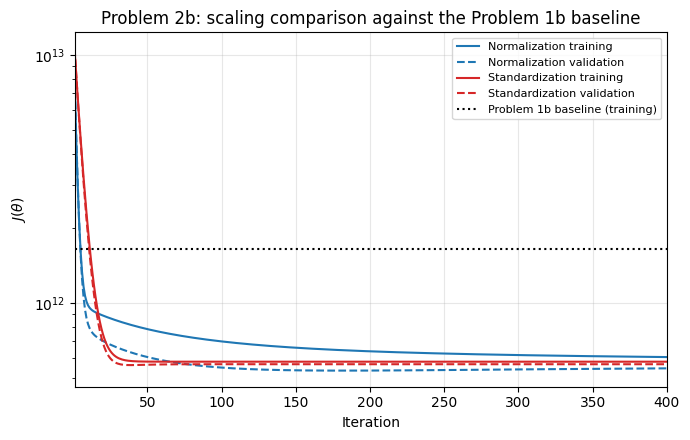

In [ ]:
S2b = run_scaling_study(FEAT_B, '2b')
print('\nfinal theta at lr=0.1')
print('  normalization  :', np.round(S2b['norm']['runs'][0.1]['theta'], 2))
print('  standardization:', np.round(S2b['std']['runs'][0.1]['theta'], 2))
plot_scaling(S2b, '2b', tr_1b[-1], '1b')

In [ ]:
# Summary table: baseline vs normalization vs standardization, same iteration budget.
def row(nm, Xtr, Xva, th):
    return (f'{nm:<34}{compute_cost(add_bias(Xtr), ytr, th):>15.5e}'
            f'{compute_cost(add_bias(Xva), yva, th):>15.5e}'
            f'{r2_score_manual(Xtr, ytr, th):>11.4f}{r2_score_manual(Xva, yva, th):>10.4f}')

hdr = f'{"":<34}{"J_train":>15}{"J_val":>15}{"R2_train":>11}{"R2_val":>10}'
print('PROBLEM 2a  (5 inputs)'); print(hdr)
print(row('1a baseline, no scaling', Xtr_1a, Xva_1a, th_1a))
print(row('2a normalization, lr=0.1',  S2a['norm']['Xtr'], S2a['norm']['Xva'], S2a['norm']['runs'][0.1]['theta']))
print(row('2a standardization, lr=0.1', S2a['std']['Xtr'],  S2a['std']['Xva'],  S2a['std']['runs'][0.1]['theta']))
print()
print('PROBLEM 2b  (11 inputs)'); print(hdr)
print(row('1b baseline, no scaling', Xtr_1b, Xva_1b, th_1b))
print(row('2b normalization, lr=0.1',  S2b['norm']['Xtr'], S2b['norm']['Xva'], S2b['norm']['runs'][0.1]['theta']))
print(row('2b standardization, lr=0.1', S2b['std']['Xtr'],  S2b['std']['Xva'],  S2b['std']['runs'][0.1]['theta']))

PROBLEM 2a  (5 inputs)
                                          J_train          J_val   R2_train    R2_val
1a baseline, no scaling               1.64959e+12    1.77039e+12     0.0524   -0.0037
2a normalization, lr=0.1              7.73544e+11    7.50915e+11     0.5557    0.5743
2a standardization, lr=0.1            7.73544e+11    7.50915e+11     0.5557    0.5743

PROBLEM 2b  (11 inputs)
                                          J_train          J_val   R2_train    R2_val
1b baseline, no scaling               1.64940e+12    1.77020e+12     0.0525   -0.0036
2b normalization, lr=0.1              5.79433e+11    5.65923e+11     0.6672    0.6791
2b standardization, lr=0.1            5.79433e+11    5.65923e+11     0.6672    0.6791


---
# Problem 3: adding an L2 parameter penalty

Standardization is the better scaling in Problem 2, so it is the one used here.
The penalty enters the **training** update only. The evaluation loss is left as the plain
$\frac{1}{2m}\sum (h-y)^2$, exactly as the homework specifies.

In [ ]:
LAMBDAS = [0.0, 1.0, 10.0, 100.0, 1000.0]

def run_regularization(feats, tag):
    Xtr, Xva = get_data(feats, 'std')
    m = len(ytr)
    L = hessian_eigs(Xtr).max()
    lam_max = m * (2/0.1 - L)
    print(f'stability needs alpha*max_eig((1/m)Xb\'Xb + (lambda/m)D) < 2, i.e. '
          f'lambda < m*(2/alpha - L) = {lam_max:.1f}   (L = {L:.4f})')
    out = {'Xtr': Xtr, 'Xva': Xva, 'runs': {}, 'lam_max': lam_max}
    print(f'{"lambda":>8}{"J_train (plain)":>19}{"J_train (+penalty)":>21}{"J_val":>16}'
          f'{"R2_train":>11}{"R2_val":>10}{"sum theta_j^2":>16}')
    for lam in LAMBDAS:
        th, tr, trr, va, dv = gradient_descent(Xtr, ytr, Xva, yva, 0.1, N_ITER, lam=lam)
        out['runs'][lam] = {'theta': th, 'tr': tr, 'trr': trr, 'va': va}
        print(f'{lam:>8g}{tr[-1]:>19.6e}{trr[-1]:>21.6e}{va[-1]:>16.6e}'
              f'{r2_score_manual(Xtr, ytr, th):>11.4f}{r2_score_manual(Xva, yva, th):>10.4f}'
              f'{np.sum(th[1:]**2):>16.4e}')
    best = min(LAMBDAS, key=lambda L: out['runs'][L]['va'][-1])
    out['best'] = best
    print(f'\nlowest evaluation loss at lambda = {best:g}')
    print('theta at lambda=0        :', np.round(out['runs'][0.0]['theta'], 1))
    print(f'theta at lambda={best:g}      :', np.round(out['runs'][best]['theta'], 1))
    print(f'\nstability check around the bound lambda < {lam_max:.0f}')
    for lam_test in [round(lam_max*0.97, -1), round(lam_max*1.02, -1), 10000.0]:
        with np.errstate(over='ignore', invalid='ignore'):
            _, trx, _, _, dvx = gradient_descent(Xtr, ytr, Xva, yva, 0.1, 40000, lam=lam_test)
        side = 'below' if lam_test < lam_max else 'above'
        verdict = f'overflows at iteration {dvx}' if dvx else (
            'stays finite' if trx[-1] < trx[0]*10 else f'growing without bound (J={trx[-1]:.2e})')
        print(f'  lambda={lam_test:>8g} ({side} bound): {verdict}')
    return out

def plot_regularization(R, tag, base_name):
    best = R['best']
    r    = R['runs'][best]
    r0   = R['runs'][0.0]
    it   = np.arange(1, len(r['tr']) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

    ax[0].plot(it, r['tr'],  c='tab:blue', label=f'Training loss (plain), lambda={best:g}')
    ax[0].plot(it, r['trr'], c='tab:blue', ls='--', lw=1, label=f'Training objective (with penalty), lambda={best:g}')
    ax[0].plot(it, r['va'],  c='tab:red',  label=f'Validation loss, lambda={best:g}')
    ax[0].plot(it, r0['va'], c='gray', ls=':', label=f'Validation loss, lambda=0 (Problem {base_name})')
    lo = min(r['va'][-1], r['tr'][-1], r0['va'][-1])
    hi = max(r['trr'][-1], r0['va'][-1], r['tr'][-1])
    ax[0].set_xlim(1, 300); ax[0].set_ylim(lo*0.93, hi*1.10)
    ax[0].set_xlabel('Iteration'); ax[0].set_ylabel(r'$J(\theta)$')
    ax[0].set_title(f'Problem {tag}: standardized inputs, lr=0.1, lambda={best:g}')
    ax[0].legend(fontsize=7.5)
    gain = 100*(r0['va'][-1] - r['va'][-1])/r0['va'][-1]
    ax[0].annotate(f'validation loss {gain:.1f}% lower\n({r0["va"][-1]:.4e} -> {r["va"][-1]:.4e})',
                   xy=(300, r['va'][-1]), xytext=(150, lo*0.96), fontsize=7.5, ha='left',
                   arrowprops=dict(arrowstyle='->', lw=0.8, color='0.3'))

    finals = [R['runs'][l]['va'][-1] for l in LAMBDAS]
    xs = np.arange(len(LAMBDAS))
    ax[1].plot(xs, finals, marker='o', c='tab:red')
    ax[1].axhline(finals[0], c='gray', ls=':', lw=1, label='lambda = 0 baseline')
    bi = LAMBDAS.index(best)
    ax[1].scatter([xs[bi]], [finals[bi]], s=140, facecolors='none', edgecolors='tab:green',
                  linewidths=2, zorder=5, label=f'best: lambda = {best:g}')
    ax[1].set_xticks(xs); ax[1].set_xticklabels([f'{l:g}' for l in LAMBDAS])
    ax[1].set_yscale('log')
    ax[1].set_xlabel('lambda'); ax[1].set_ylabel(r'Final validation $J(\theta)$')
    ax[1].set_title(f'Problem {tag}: validation loss vs regularization strength')
    ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Problem 3a: the five input variables, standardized, with the penalty

stability needs alpha*max_eig((1/m)Xb'Xb + (lambda/m)D) < 2, i.e. lambda < m*(2/alpha - L) = 7896.9   (L = 1.8878)
  lambda    J_train (plain)   J_train (+penalty)           J_val   R2_train    R2_val   sum theta_j^2
       0       7.735444e+11         7.735444e+11    7.509154e+11     0.5557    0.5743      1.2235e+12
       1       7.735469e+11         7.749451e+11    7.502612e+11     0.5557    0.5746      1.2192e+12
      10       7.737838e+11         7.873308e+11    7.448455e+11     0.5555    0.5777      1.1813e+12
     100       7.903927e+11         8.934021e+11    7.233545e+11     0.5460    0.5899      8.9824e+11
    1000       1.095316e+12         1.327572e+12    1.007534e+12     0.3708    0.4288      2.0253e+11

lowest evaluation loss at lambda = 100
theta at lambda=0        : [4749522.   719953.1  103996.6  624093.2  469274.1  290992.9]
theta at lambda=100      : [4749522.   601294.   156005.8  531304.3  393082.9  274865.7]

stability check around the bound lambda < 7897
  lambd

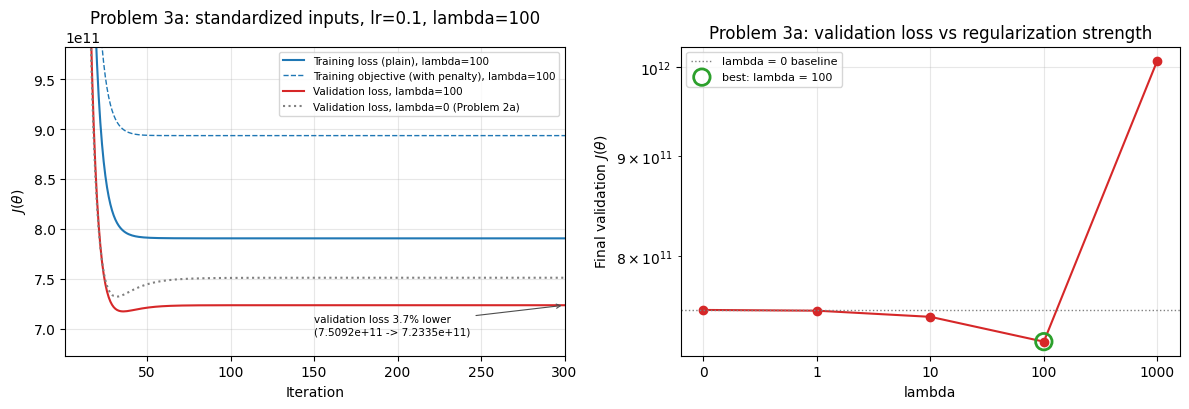

In [ ]:
R3a = run_regularization(FEAT_A, '3a')
plot_regularization(R3a, '3a', '2a')

## Problem 3b: all eleven input variables, standardized, with the penalty

stability needs alpha*max_eig((1/m)Xb'Xb + (lambda/m)D) < 2, i.e. lambda < m*(2/alpha - L) = 7717.1   (L = 2.3003)
  lambda    J_train (plain)   J_train (+penalty)           J_val   R2_train    R2_val   sum theta_j^2
       0       5.794335e+11         5.794335e+11    5.659235e+11     0.6672    0.6791      1.1719e+12
       1       5.794355e+11         5.807754e+11    5.653594e+11     0.6672    0.6795      1.1684e+12
      10       5.796263e+11         5.926755e+11    5.606421e+11     0.6671    0.6821      1.1379e+12
     100       5.933516e+11         6.971855e+11    5.391378e+11     0.6592    0.6943      9.0543e+11
    1000       8.953438e+11         1.180168e+12    8.035446e+11     0.4857    0.5444      2.4837e+11

lowest evaluation loss at lambda = 100
theta at lambda=0        : [4749522.   551915.3   86950.6  558892.5  370529.5  162635.5  132792.1  101036.2  200461.7  395521.5  224572.3  329731.8]
theta at lambda=100      : [4749522.   471688.   135357.2  477353.7  319519.1  16893

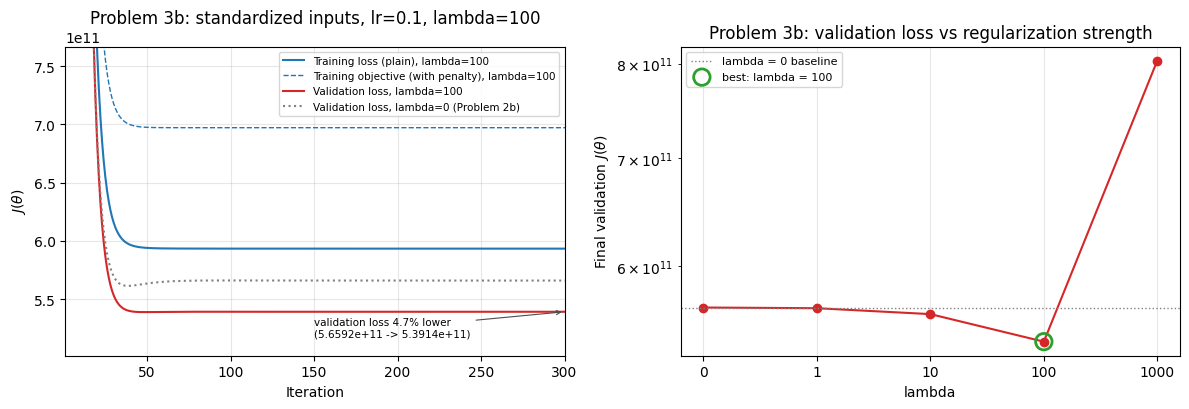

In [ ]:
R3b = run_regularization(FEAT_B, '3b')
plot_regularization(R3b, '3b', '2b')

---
# Final summary across all six problems

In [ ]:
print(f'{"model":<44}{"J_train":>15}{"J_val":>15}{"R2_val":>10}')
print('-'*84)
rows = [
    ('1a  5 inputs, no scaling',          Xtr_1a, Xva_1a, th_1a),
    ('2a  5 inputs, normalization',       S2a['norm']['Xtr'], S2a['norm']['Xva'], S2a['norm']['runs'][0.1]['theta']),
    ('2a  5 inputs, standardization',     S2a['std']['Xtr'],  S2a['std']['Xva'],  S2a['std']['runs'][0.1]['theta']),
    (f'3a  5 inputs, std + lambda={R3a["best"]:g}',  R3a['Xtr'], R3a['Xva'], R3a['runs'][R3a['best']]['theta']),
    ('1b  11 inputs, no scaling',         Xtr_1b, Xva_1b, th_1b),
    ('2b  11 inputs, normalization',      S2b['norm']['Xtr'], S2b['norm']['Xva'], S2b['norm']['runs'][0.1]['theta']),
    ('2b  11 inputs, standardization',    S2b['std']['Xtr'],  S2b['std']['Xva'],  S2b['std']['runs'][0.1]['theta']),
    (f'3b  11 inputs, std + lambda={R3b["best"]:g}', R3b['Xtr'], R3b['Xva'], R3b['runs'][R3b['best']]['theta']),
]
for nm, X1, X2, th in rows:
    print(f'{nm:<44}{compute_cost(add_bias(X1), ytr, th):>15.5e}'
          f'{compute_cost(add_bias(X2), yva, th):>15.5e}{r2_score_manual(X2, yva, th):>10.4f}')

model                                               J_train          J_val    R2_val
------------------------------------------------------------------------------------
1a  5 inputs, no scaling                        1.64959e+12    1.77039e+12   -0.0037
2a  5 inputs, normalization                     7.73544e+11    7.50915e+11    0.5743
2a  5 inputs, standardization                   7.73544e+11    7.50915e+11    0.5743
3a  5 inputs, std + lambda=100                  7.90393e+11    7.23354e+11    0.5899
1b  11 inputs, no scaling                       1.64940e+12    1.77020e+12   -0.0036
2b  11 inputs, normalization                    5.79433e+11    5.65923e+11    0.6791
2b  11 inputs, standardization                  5.79433e+11    5.65923e+11    0.6791
3b  11 inputs, std + lambda=100                 5.93352e+11    5.39138e+11    0.6943
